# Playing Atari with Deep Reinforcement Learning — Reproduction Notebook

Reproduces Mnih, Kavukcuoglu, Silver, Graves, Antonoglou, Wierstra, Riedmiller,
**"Playing Atari with Deep Reinforcement Learning"** (DeepMind, NIPS Deep
Learning Workshop, 2013) — the first deep RL agent to learn to play Atari
2600 games directly from raw pixels, using a single convolutional network
trained with Q-learning and experience replay, with no game-specific feature
engineering.

This notebook walks through the paper section by section, and for every
section runs the actual project code rather than re-deriving it:

| Paper section | This notebook's section | Project file |
|---|---|---|
| 2. Background | Background | — (conceptual) |
| 3. Related Work | Related Work | — (conceptual) |
| 4.1 Preprocessing | Preprocessing pipeline (with sample screens) | `atari_preprocessing.py` |
| 4.1 Model Architecture | Network architecture | `dqn_model.py` |
| 4 / Algorithm 1 | Deep Q-learning with Experience Replay | `dqn_train_backup.py` |
| 5.1 Training and Stability | Training + measuring progress | `dqn_train_backup.py`, reward/avg-max-Q plots |
| 5.3 Evaluation | Evaluation (epsilon=0.05 convention) | `dqn_evaluate.py` |
| — | Watching it play (sample frames) | `dqn_evaluate.py` (`record=True`) |

**Why `dqn_train_backup.py`, not `dqn_train.py`:** this repo's `dqn_train.py`
was later extended with a target network, Huber loss, and gradient clipping
— three stability improvements from the 2015 *Nature* DQN follow-up, adopted
here as a documented, deliberate deviation (see `DQN_Training_Guide.md` Step
8). Since this notebook's purpose is reproducing the **2013 paper itself**,
it trains via `dqn_train_backup.py`, an unmodified snapshot of the original
Algorithm 1 (no target network, MSE loss, no gradient clipping). Expect to
see the instability the paper's later follow-up specifically fixed — that's
a documented, expected part of reproducing the original algorithm faithfully.

**Scale:** to keep this notebook runnable in minutes rather than the paper's
~1 week (2013 hardware) / ~10,000,000 frames, several hyperparameters are
reduced (see `dqn_train_backup.py`'s hyperparameter block) — this reproduces
the paper's *algorithm* exactly, not its *scale*. See `DQN_GPU_Speedup_Guide.md`
and `DQN_Colab_T4_Guide.md` for notes on running much larger training faster.


In [1]:
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt

import dqn_model
import atari_preprocessing
import dqn_train_backup as dqn_paper   # the paper-faithful Algorithm 1 implementation
import dqn_evaluate

print("torch:", torch.__version__)
print("Training module in use: dqn_train_backup.py (paper-faithful Algorithm 1)")
print("USE_TOY_ENV =", dqn_paper.USE_TOY_ENV, "| GAME_ID =", dqn_paper.GAME_ID)


torch: 2.11.0
Training module in use: dqn_train_backup.py (paper-faithful Algorithm 1)
USE_TOY_ENV = False | GAME_ID = ALE/Breakout-v5


## 2. Background

The paper frames Atari play as a Markov Decision Process: at each timestep
the agent observes a state $s_t$ (a game screen), takes an action $a_t$ from
a finite set, and receives a reward $r_t$. The goal is to learn a policy
that maximizes cumulative future (discounted) reward.

The optimal action-value function is defined as
$Q^*(s,a) = \max_\pi \, \mathbb{E}[R_t \mid s_t=s, a_t=a, \pi]$ — the best
possible expected return from taking action $a$ in state $s$ and acting
optimally afterward. It obeys the Bellman equation:
$Q^*(s,a) = \mathbb{E}_{s'}\left[r + \gamma \max_{a'} Q^*(s',a') \mid s,a\right]$.

A raw Atari screen has far too many possible states to keep a lookup table
of $Q(s,a)$ values (this is exactly why the paper uses a neural network
$Q(s,a;\theta)$ as a function approximator instead — the network's job is to
generalize across the astronomically large state space of raw pixels).

## 3. Related Work

The paper contrasts its approach with prior RL work that relied on linear
function approximators or hand-engineered features over low-dimensional
state representations (e.g. TD-Gammon's success with a multi-layer
perceptron on backgammon, and earlier attempts at Atari with more limited
feature representations). The core contribution here is using the *same*
raw-pixel input and a *single* convolutional architecture across seven very
different games, with no per-game feature engineering.

## 4.1 Preprocessing — from raw Atari pixels to $\phi(s_t)$

Section 4.1's pipeline, implemented in `atari_preprocessing.py`'s
`AtariPreprocessor`:

1. Capture a raw frame: 210×160 RGB, 128-color palette.
2. Convert RGB → grayscale.
3. Down-sample to 110×84.
4. Crop to an 84×84 square (the GPU convolution implementation used in the
   paper required square input).
5. Stack the last 4 preprocessed frames → final `(84, 84, 4)` input, giving
   the network a short motion history (needed since a single frame can't
   convey velocity/direction, e.g. of the ball in Breakout).

The cell below captures **actual frames from the real Atari environment**
(falling back to a synthetic frame if the ALE ROMs aren't installed on this
machine, so the notebook still runs) and shows every stage of the pipeline
visually.

In [2]:
try:
    env = dqn_paper.make_env()
    obs, info = env.reset()
    real_env_available = True
    print("Using the real Atari environment for this demo.")
except Exception as e:
    print(f"Real Atari environment unavailable ({e!r}); "
          f"falling back to a synthetic frame for this demo.")
    real_env_available = False

pre = atari_preprocessing.AtariPreprocessor()
pre.reset()

if real_env_available:
    raw_first = obs                      # (210, 160, 3) straight from the emulator
    stacked = pre.step(raw_first)
    # step a few more times so the 4-frame stack shows genuinely different moments
    for _ in range(3):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        stacked = pre.step(obs)
        if terminated or truncated:
            obs, info = env.reset()
            pre.reset()
    env.close()
else:
    raw_first = atari_preprocessing._make_synthetic_atari_frame()
    stacked = pre.step(raw_first)
    for i in range(3):
        f = atari_preprocessing._make_synthetic_atari_frame()
        stacked = pre.step(f)

gray = pre.to_grayscale(raw_first)
resized = pre.downsample(gray)
cropped = pre.crop(resized)

print("1. Raw frame        :", raw_first.shape, raw_first.dtype)
print("2. Grayscale         :", gray.shape)
print("3. Downsampled 110x84:", resized.shape)
print("4. Cropped 84x84     :", cropped.shape)
print("5. Stacked phi(s_t)  :", stacked.shape, "(expected (84, 84, 4))")


Using the real Atari environment for this demo.
1. Raw frame        : (210, 160, 3) uint8
2. Grayscale         : (210, 160)
3. Downsampled 110x84: (110, 84)
4. Cropped 84x84     : (84, 84)
5. Stacked phi(s_t)  : (84, 84, 4) (expected (84, 84, 4))


A.L.E: Arcade Learning Environment (version 0.12.1+8a8fafb)
[Powered by Stella]


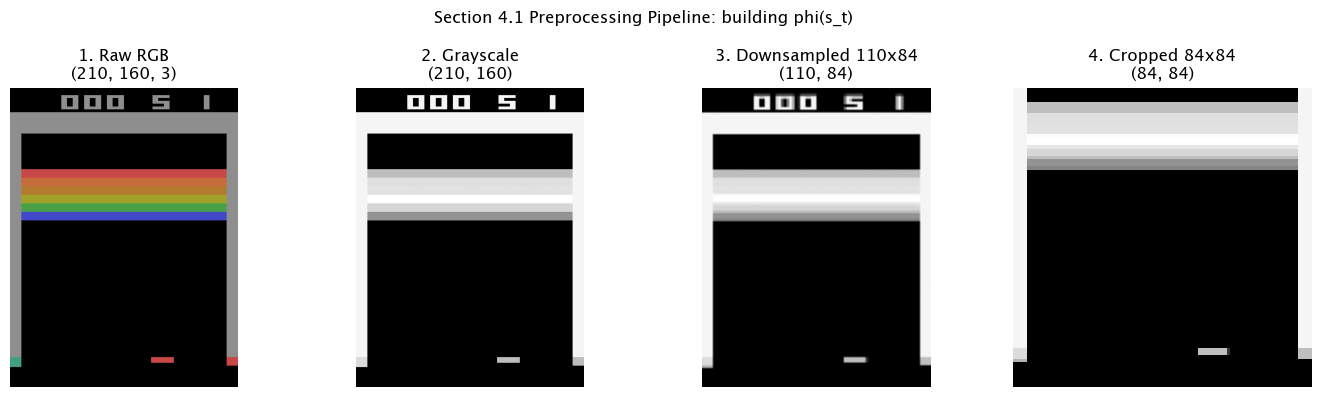

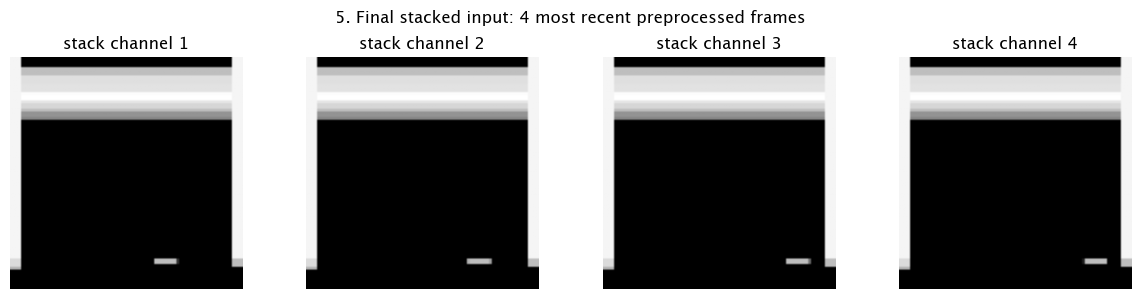

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes[0].imshow(raw_first)
axes[0].set_title(f"1. Raw RGB\n{raw_first.shape}")
axes[1].imshow(gray, cmap="gray")
axes[1].set_title(f"2. Grayscale\n{gray.shape}")
axes[2].imshow(resized, cmap="gray")
axes[2].set_title(f"3. Downsampled 110x84\n{resized.shape}")
axes[3].imshow(cropped, cmap="gray")
axes[3].set_title(f"4. Cropped 84x84\n{cropped.shape}")
for ax in axes:
    ax.axis("off")
plt.suptitle("Section 4.1 Preprocessing Pipeline: building phi(s_t)")
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes2[i].imshow(stacked[..., i], cmap="gray")
    axes2[i].set_title(f"stack channel {i + 1}")
    axes2[i].axis("off")
plt.suptitle("5. Final stacked input: 4 most recent preprocessed frames")
plt.tight_layout()
plt.show()


## 4.1 Model architecture — $Q(s,a;\theta)$

Section 4.1's network, implemented in `dqn_model.py`'s `DQN` class:

```
Input:   84 x 84 x 4   (4 stacked grayscale frames)
Conv1:   16 filters, 8x8, stride 4, ReLU        -> 20 x 20 x 16
Conv2:   32 filters, 4x4, stride 2, ReLU        ->  9 x  9 x 32
Flatten:                                        -> 2592
FC1:     256 units, ReLU                        -> 256
Output:  linear, one unit per valid action       -> num_actions  (raw Q-values)
```

One forward pass produces a Q-value for **every** action simultaneously —
required both for acting (argmax over actions) and for training (max over
actions in the Bellman target). No pooling layers are used, since pooling
would blur the precise spatial position of small, fast-moving objects (e.g.
the ball). The cell below reuses `dqn_model.py`'s own shape-verification
self-test rather than re-deriving it.

In [4]:
net_check = dqn_model._self_test()


Building DQN and verifying layer shapes against the paper...

Input                : (8, 4, 84, 84)  (expected (batch, 4, 84, 84))
After Conv1 + ReLU    : (8, 16, 20, 20)  (expected (batch, 16, 20, 20))
After Conv2 + ReLU    : (8, 32, 9, 9)  (expected (batch, 32, 9, 9))
After Flatten         : (8, 2592)  (expected (batch, 2592))
After FC1 + ReLU      : (8, 256)  (expected (batch, 256))
Output (Q-values)     : (8, 4)  (expected (batch, 4))

Total trainable parameters: 677,172

Self-test passed: all shapes match the paper's architecture.


## 4 / Algorithm 1 — Deep Q-learning with Experience Replay

```
Initialize replay memory D to capacity N
Initialize Q with random weights theta
for episode = 1 to M:
    initialise s1, phi1 = phi(s1)
    for t = 1 to T:
        with probability eps select random action a_t
        otherwise select a_t = argmax_a Q(phi(s_t), a; theta)
        execute a_t, observe r_t, x_t+1
        set s_t+1, compute phi_t+1
        store (phi_t, a_t, r_t, phi_t+1) in D
        sample random minibatch from D
        y_j = r_j                                  if terminal
        y_j = r_j + gamma * max_a' Q(phi_j+1, a'; theta)   otherwise
        gradient descent step on (y_j - Q(phi_j, a_j; theta))^2
```

Mapping onto `dqn_train_backup.py`:

| Pseudocode line | Function / code |
|---|---|
| Replay memory D | `ReplayMemory` (a `deque(maxlen=REPLAY_CAPACITY)`) |
| epsilon-greedy behaviour policy | `select_action()`, `epsilon_by_step()` |
| store transition in D | `replay.push(...)` |
| Bellman target $y_j$ + SGD step | the `torch.no_grad()` block + `nn.MSELoss()` + `RMSprop` inside `train()` |

The reward-clipping rule from Section 5 ("fixed all positive rewards to be 1
and all negative rewards to be −1, leaving 0 rewards unchanged") is
implemented in `clip_reward()`, applied only to what's *stored* in replay
(the *logged* episode reward stays the true, unclipped game score, matching
Section 5.3's evaluation convention).

A quick, isolated look at two of these pieces before running full training:

In [5]:
# Illustrative only -- full training (below) exercises the real environment.
demo_replay = dqn_paper.ReplayMemory(capacity=100)
rng_state = np.random.RandomState(0)
for _ in range(10):
    phi = rng_state.rand(84, 84, 4).astype(np.float32)
    next_phi = rng_state.rand(84, 84, 4).astype(np.float32)
    action = rng_state.randint(4)
    reward = float(rng_state.choice([-1.0, 0.0, 1.0]))
    done = bool(rng_state.rand() < 0.1)
    demo_replay.push(phi, action, reward, next_phi, done)

phis, actions, rewards, next_phis, dones = demo_replay.sample(4)
print("Replay buffer size:", len(demo_replay))
print("Sampled minibatch shapes:", phis.shape, actions.shape, rewards.shape, next_phis.shape, dones.shape)

print("\nEpsilon schedule (linear anneal, Section 5):")
for step in [0, dqn_paper.EPS_DECAY_STEPS // 2, dqn_paper.EPS_DECAY_STEPS, dqn_paper.EPS_DECAY_STEPS * 2]:
    print(f"  step {step:>7d} -> epsilon = {dqn_paper.epsilon_by_step(step):.3f}")


Replay buffer size: 10
Sampled minibatch shapes: (4, 84, 84, 4) (4,) (4,) (4, 84, 84, 4) (4,)

Epsilon schedule (linear anneal, Section 5):
  step       0 -> epsilon = 1.000
  step   10000 -> epsilon = 0.550
  step   20000 -> epsilon = 0.100
  step   40000 -> epsilon = 0.100


## 5.1 Training and Stability — running Algorithm 1

**If the real Atari ROMs aren't installed on your machine**, set
`dqn_paper.USE_TOY_ENV = True` before running the next cell to train against
the dependency-free `toy_pixel_env.SimpleCatchEnv` instead — it mirrors
gymnasium's `reset()`/`step()`/`render()` interface, so every line below
works unchanged either way.

`NUM_EPISODES_DEMO` is kept modest (see comment) so this cell finishes in
minutes; raise it for a closer reproduction (the paper itself trained on
~10,000,000 frames).

In [6]:
NUM_EPISODES_DEMO = 60   # ~4-5 min on a laptop CPU for real Atari, extrapolating
                        # from the ~5 min / 80-episode benchmark in
                        # DQN_Training_Guide.md. Raise this if you have more
                        # time -- see DQN_GPU_Speedup_Guide.md and
                        # DQN_Colab_T4_Guide.md for running many more
                        # episodes faster.

net, episode_rewards, avg_q_history, loss_history = dqn_paper.train(num_episodes=NUM_EPISODES_DEMO)


Environment: ALE/Breakout-v5 | actions = 4
Episode    5 | avg reward (last 5) = +0.80 | avg max Q =  0.280 | eps = 0.962 | loss = nan
Episode   10 | avg reward (last 5) = +1.80 | avg max Q = 17.783 | eps = 0.914 | loss = 4.5405
Episode   15 | avg reward (last 5) = +0.40 | avg max Q =  5.032 | eps = 0.880 | loss = 0.1269
Episode   20 | avg reward (last 5) = +1.20 | avg max Q = 261.706 | eps = 0.838 | loss = 3724.0300
Episode   25 | avg reward (last 5) = +1.00 | avg max Q = 12.713 | eps = 0.800 | loss = 0.9895
Episode   30 | avg reward (last 5) = +0.40 | avg max Q = 10.770 | eps = 0.767 | loss = 0.5446
Episode   35 | avg reward (last 5) = +1.60 | avg max Q = 11.963 | eps = 0.723 | loss = 0.6491
Episode   40 | avg reward (last 5) = +1.40 | avg max Q = 10.817 | eps = 0.679 | loss = 1.0185
Episode   45 | avg reward (last 5) = +1.40 | avg max Q = 13.688 | eps = 0.640 | loss = 0.8330
Episode   50 | avg reward (last 5) = +1.80 | avg max Q = 16.361 | eps = 0.595 | loss = 1.2784
Episode   55 | a

In [7]:
# Save this notebook run's weights/history under their own filenames --
# deliberately NOT dqn_breakout.pt / dqn_training_history_breakout.npz, so this
# demo run doesn't overwrite any existing checkpoint from dqn_train.py runs.
torch.save(net.state_dict(), "dqn_breakout_paper_notebook.pt")
np.savez("dqn_training_history_breakout_paper_notebook.npz",
         episode_rewards=np.array(episode_rewards),
         avg_q_history=np.array(avg_q_history),
         loss_history=np.array(loss_history))
print("Saved dqn_breakout_paper_notebook.pt and dqn_training_history_breakout_paper_notebook.npz")


Saved dqn_breakout_paper_notebook.pt and dqn_training_history_breakout_paper_notebook.npz


## 5.1 Measuring training progress

Section 5.1's key observation: raw per-episode reward is a *very noisy*
metric ("small changes to the weights of a policy can lead to large changes
in the distribution of states the policy visits"), so the paper also tracks
the network's average predicted max-Q on a **fixed** held-out set of states
collected once, before training, via a random policy
(`collect_eval_states()` in `dqn_train_backup.py`). In the paper's full-scale
runs this metric rises smoothly. Reproduced here at reduced scale, expect to
see it spike instead — a known, literature-documented consequence of
Algorithm 1's lack of a target network (see `DQN_Training_Guide.md` Step 8;
`dqn_train.py` implements the fix, deliberately not used in this notebook so
it stays faithful to the original paper).

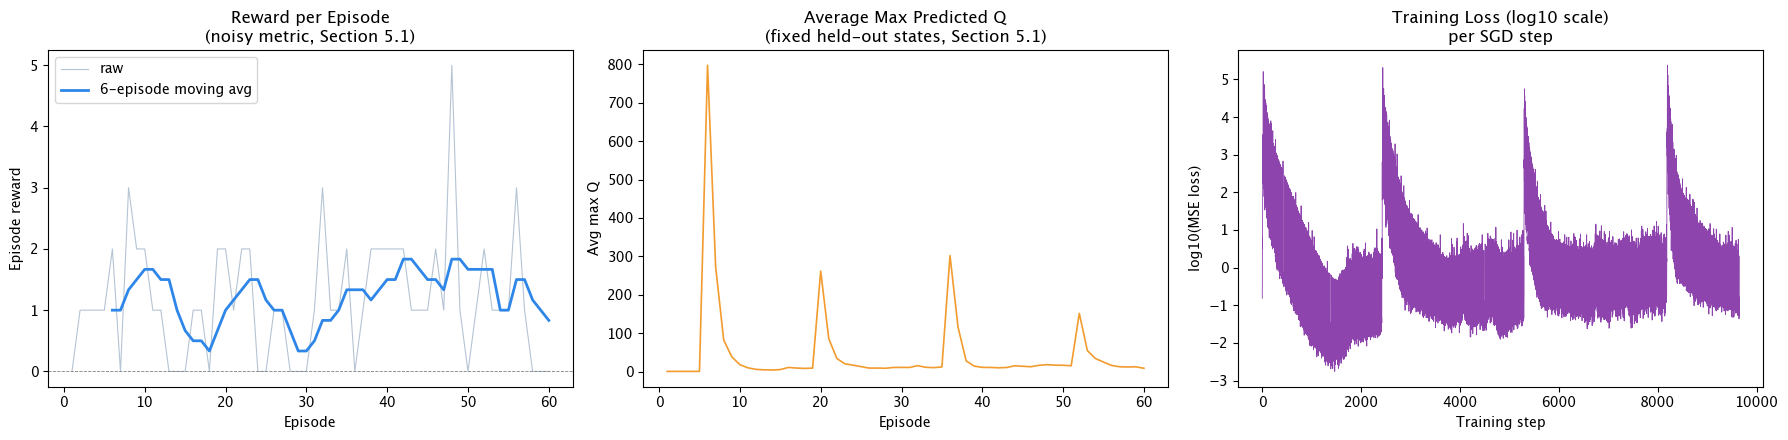

--- Summary ---
Episodes trained         : 60
Mean reward (first 10%)  : +1.000
Mean reward (last 10%)   : +0.833
Final avg max Q          : +8.469
Max |avg max Q| observed : 798.000  (large spikes here reflect the known instability of the original Algorithm 1 without a target network)


In [8]:
def moving_average(x, window):
    x = np.asarray(x)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

episode_rewards_arr = np.array(episode_rewards)
avg_q_arr = np.array(avg_q_history)
loss_arr = np.array(loss_history)

episodes = np.arange(1, len(episode_rewards_arr) + 1)
window = max(5, len(episode_rewards_arr) // 10)
smoothed = moving_average(episode_rewards_arr, window)
smoothed_episodes = episodes[window - 1:] if len(episode_rewards_arr) >= window else episodes

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(episodes, episode_rewards_arr, color="#B5C4D4", linewidth=0.8, label="raw")
axes[0].plot(smoothed_episodes, smoothed, color="#2E86E8", linewidth=2.0, label=f"{window}-episode moving avg")
axes[0].axhline(0, color="grey", linewidth=0.6, linestyle="--")
axes[0].set_title("Reward per Episode\n(noisy metric, Section 5.1)")
axes[0].set_xlabel("Episode"); axes[0].set_ylabel("Episode reward"); axes[0].legend()

axes[1].plot(episodes, avg_q_arr, color="#F29B2E", linewidth=1.2)
axes[1].set_title("Average Max Predicted Q\n(fixed held-out states, Section 5.1)")
axes[1].set_xlabel("Episode"); axes[1].set_ylabel("Avg max Q")

if len(loss_arr) > 0:
    steps = np.arange(1, len(loss_arr) + 1)
    axes[2].plot(steps, np.log10(np.clip(loss_arr, 1e-8, None)), color="#8E44AD", linewidth=0.6)
    axes[2].set_title("Training Loss (log10 scale)\nper SGD step")
    axes[2].set_xlabel("Training step"); axes[2].set_ylabel("log10(MSE loss)")

plt.tight_layout()
plt.show()

tenth = max(1, len(episode_rewards_arr) // 10)
print("--- Summary ---")
print(f"Episodes trained         : {len(episode_rewards_arr)}")
print(f"Mean reward (first 10%)  : {episode_rewards_arr[:tenth].mean():+.3f}")
print(f"Mean reward (last 10%)   : {episode_rewards_arr[-tenth:].mean():+.3f}")
print(f"Final avg max Q          : {avg_q_arr[-1]:+.3f}")
print(f"Max |avg max Q| observed : {np.max(np.abs(avg_q_arr)):.3f}  "
      f"(large spikes here reflect the known instability of the original "
      f"Algorithm 1 without a target network)")


## 5.3 Evaluation

Section 5.3's evaluation convention: run the trained network with an
**epsilon-greedy policy at epsilon = 0.05** (not fully greedy) for a number
of episodes, and report the average score. A purely greedy policy risks
getting stuck looping an identical trajectory on a near-deterministic
emulator; a small amount of randomness avoids that and better reflects real
play. This reuses `dqn_evaluate.py`'s `make_env()` and `run_episode()`
directly rather than re-implementing evaluation here.

In [10]:
net.eval()   # correct practice before using the network purely for inference

eval_env = dqn_evaluate.make_env(dqn_paper.GAME_ID, use_toy=dqn_paper.USE_TOY_ENV)
eval_preprocessor = atari_preprocessing.AtariPreprocessor()
num_actions = eval_env.action_space.n

EVAL_EPISODES = 20
EVAL_EPSILON = 0.05   # paper Section 5.3's evaluation convention

eval_rewards = []
for ep in range(1, EVAL_EPISODES + 1):
    reward, steps, _ = dqn_evaluate.run_episode(
        eval_env, net, eval_preprocessor, EVAL_EPSILON, num_actions, record=False
    )
    eval_rewards.append(reward)
    print(f"Episode {ep:2d}: reward = {reward:.1f}, steps = {steps}")

eval_env.close()
print(f"\nAverage reward over {EVAL_EPISODES} episodes (epsilon={EVAL_EPSILON}): "
      f"{np.mean(eval_rewards):.2f} (+/- {np.std(eval_rewards):.2f})")


Episode  1: reward = 3.0, steps = 268
Episode  2: reward = 2.0, steps = 199
Episode  3: reward = 3.0, steps = 268
Episode  4: reward = 2.0, steps = 219
Episode  5: reward = 2.0, steps = 217
Episode  6: reward = 0.0, steps = 122
Episode  7: reward = 0.0, steps = 123
Episode  8: reward = 4.0, steps = 296
Episode  9: reward = 0.0, steps = 122
Episode 10: reward = 1.0, steps = 151
Episode 11: reward = 0.0, steps = 122
Episode 12: reward = 2.0, steps = 197
Episode 13: reward = 2.0, steps = 218
Episode 14: reward = 4.0, steps = 280
Episode 15: reward = 1.0, steps = 150
Episode 16: reward = 0.0, steps = 122
Episode 17: reward = 2.0, steps = 220
Episode 18: reward = 1.0, steps = 170
Episode 19: reward = 1.0, steps = 151
Episode 20: reward = 0.0, steps = 122

Average reward over 20 episodes (epsilon=0.05): 1.50 (+/- 1.28)


## Bonus: watching the trained agent play

No live window is needed to get a visual sense of gameplay in a notebook —
this records one more evaluation episode (`record=True`, already supported
by `dqn_evaluate.run_episode()`) and displays a handful of sampled frames.

Recorded 1 episode: reward=2.0, steps=220, frames=221


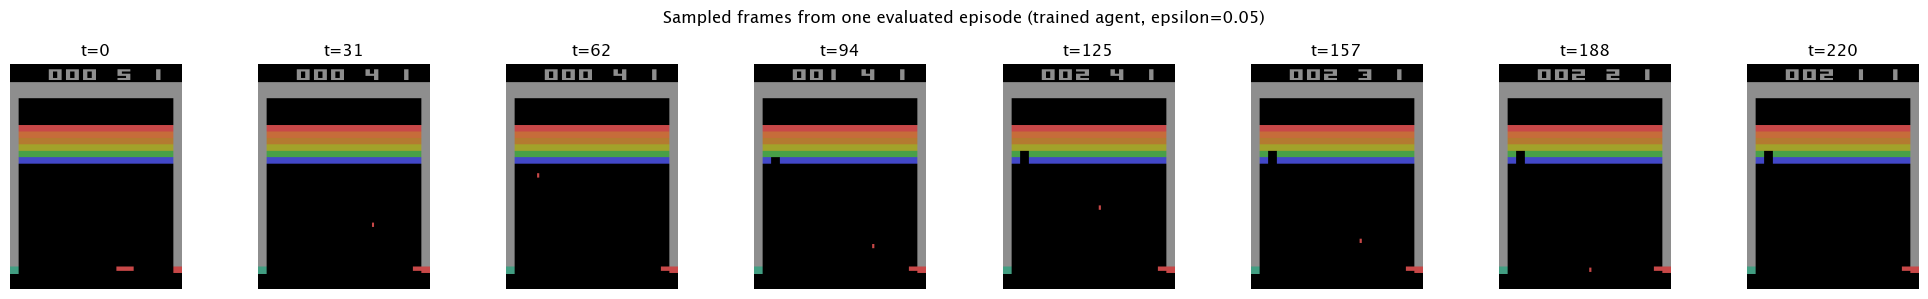

In [11]:
gif_env = dqn_evaluate.make_env(dqn_paper.GAME_ID, use_toy=dqn_paper.USE_TOY_ENV)
gif_preprocessor = atari_preprocessing.AtariPreprocessor()

reward, steps, frames = dqn_evaluate.run_episode(
    gif_env, net, gif_preprocessor, EVAL_EPSILON, num_actions, record=True
)
gif_env.close()
print(f"Recorded 1 episode: reward={reward}, steps={steps}, frames={len(frames)}")

sample_idxs = np.linspace(0, len(frames) - 1, 8).astype(int)
fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for ax, idx in zip(axes, sample_idxs):
    ax.imshow(frames[idx])
    ax.set_title(f"t={idx}")
    ax.axis("off")
plt.suptitle("Sampled frames from one evaluated episode (trained agent, epsilon=0.05)")
plt.tight_layout()
plt.show()


## 6. Conclusion / Discussion

This notebook reproduced the full pipeline described in the paper: raw
Atari pixels → preprocessing (`phi(s_t)`) → convolutional Q-network →
Algorithm 1 training with experience replay → the paper's own diagnostics
(noisy reward vs. smoother avg-max-Q) → epsilon=0.05 evaluation — all via
`dqn_train_backup.py`, an unmodified, paper-faithful implementation.

**Honest limitations (by design, for a runnable demo):**
- Hyperparameters (`REPLAY_CAPACITY`, `EPS_DECAY_STEPS`, `NUM_EPISODES_DEMO`)
  are reduced far below the paper's ~10,000,000-frame regime, so this
  demonstrates *learning*, not *paper-level play*.
- No target network / Huber loss / gradient clipping — this is the original
  2013 Algorithm 1, which is known to be less stable than the 2015 *Nature*
  follow-up. The avg-max-Q panel above is expected to show spikes for
  exactly this reason.

**Further reading in this repo:**
- `DQN_Training_Guide.md` — full step-by-step walkthrough, including Step 8's
  discussion of this instability and its fix.
- `dqn_train.py` — the stabilized version (target network + Huber loss +
  gradient clipping) built on top of this same paper-faithful base.
- `DQN_SaveLoad_Guide.md` — saving/loading/reusing trained weights.
- `DQN_GPU_Speedup_Guide.md`, `DQN_Colab_T4_Guide.md` — running larger
  training faster, including on a Colab T4 GPU.
- `dqn_watch.py` — a live, human-visible gameplay window with a stats
  overlay (an alternative to this notebook's sampled-frame-grid, for local
  use outside a notebook).